<a href="https://colab.research.google.com/github/minkyunglee-data/Portfolio/blob/Portfolio_Project/Wordcloud_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 리뷰 데이터 수집



In [8]:
pip install google-play-scraper

In [12]:
from google_play_scraper import reviews, Sort
import pandas as pd

app_id = 'com.dco.fint'

# 리뷰 수집
result, continuation_token = reviews(
    app_id,
    lang='ko',
    country='kr',
    sort=Sort.NEWEST,
    count=10000,
)

# 결과를 data frame으로 변환
df_reviews = pd.DataFrame(result)

# 별점 1점, 2점 필터링
df_filtered = df_reviews[df_reviews['score'].isin([1, 2])]

# 필요한 컬럼만 정리
df_filtered = df_filtered[['score', 'content']]

#결과 확인
print(df_filtered.head())

df_filtered.to_csv('fint_bad_reviews.csv', index=False, encoding='utf-8-sig')


    score                                            content
4       1                    테스트삼아 3달 써봤는데 마이너스폭이 점점 커지기만하는듯
5       1           1년이상 사용후기 -70만원 사진 첨부하고 싶지만 안되네요 진짜 짜증나네
6       2  자주 로그인이 풀리고, 다시 로그인 하려고 하면 신규가입하는 사람처럼 가입경위 묻는...
9       1                           비번만 틀려다고하고 인증만 무한 반복? ㅡㅡ
10      1  비밀번호 입력하면 5회이상 틀렸다고 재설정을 하는 과정을 거칩니다. 본인인증에 필요...


In [13]:
pip install konlpy wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.1/494.1 kB 25.5 MB/s eta 0:00:00


[('투자', 277), ('수익', 160), ('마이너스', 128), ('만원', 93), ('계속', 87), ('인증', 82), ('수익률', 75), ('어플', 71), ('계좌', 67), ('그냥', 66), ('출금', 64), ('손실', 64), ('수수료', 62), ('해지', 59), ('핀트', 53), ('사용', 52), ('원금', 48), ('신분증', 48), ('정도', 46), ('주식', 43)]


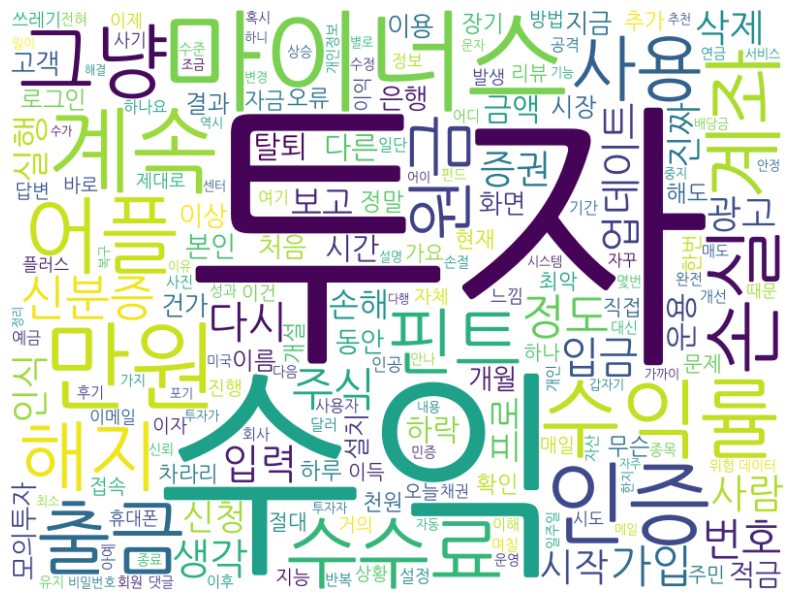

In [21]:
from konlpy.tag import Okt
from collections import Counter
from wordcloud import WordCloud
import pandas as pd
import matplotlib.pyplot as plt
import re

df = pd.read_csv('fint_bad_reviews.csv')

def clean_text(text):
    text = re.sub(r'[^가-힣\s]', '', str(text))  # 한글, 공백만 남기기
    return text

df['cleaned'] = df['content'].apply(clean_text)

# 명사만 추출
okt = Okt()
df['nouns'] = df['cleaned'].apply(lambda x: [noun for noun in okt.nouns(x) if len(noun) > 1])

# 전체 명사 리스트 생성
all_nouns = sum(df['nouns'].tolist(), [])

# 단어 빈도수 계산
noun_counts = Counter(all_nouns)
print(noun_counts.most_common(20))

# 워드클라우드 생성
wordcloud = WordCloud(
    font_path='NanumGothic.otf',
    width=800,
    height=600,
    background_color='white'
).generate_from_frequencies(noun_counts)

# 시각화 출력
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

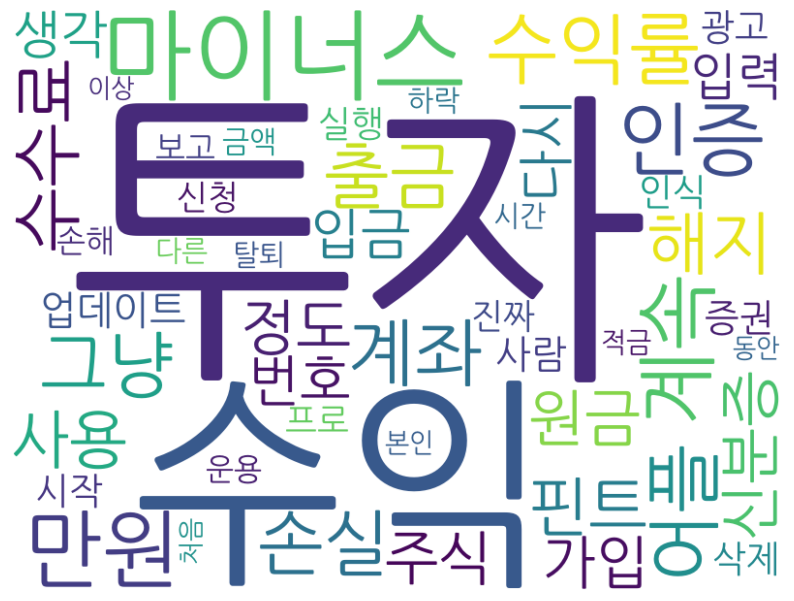

In [22]:
from konlpy.tag import Okt
from collections import Counter
from wordcloud import WordCloud
import pandas as pd
import matplotlib.pyplot as plt
import re

# 데이터 불러오기
df = pd.read_csv('fint_bad_reviews.csv')

def clean_text(text):
    text = re.sub(r'[^가-힣\s]', '', str(text))  # 한글, 공백만 남기기
    return text

df['cleaned'] = df['content'].apply(clean_text)

# 명사만 추출
okt = Okt()
df['nouns'] = df['cleaned'].apply(lambda x: [noun for noun in okt.nouns(x) if len(noun) > 1])

# 전체 명사 리스트 생성
all_nouns = sum(df['nouns'].tolist(), [])

# 단어 빈도수 계산
noun_counts = Counter(all_nouns)

#  상위 50개 단어만 추출
top_50 = dict(noun_counts.most_common(50))

# 워드클라우드 생성
wordcloud = WordCloud(
    font_path='NanumGothic.otf',  # 폰트 경로
    width=800,
    height=600,
    background_color='white'
).generate_from_frequencies(top_50)

# 시각화 출력
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()